# Retail Sales Analysis

## 1. Business Problem
Retail companies often rely on discount strategies to drive revenue growth. However, aggressive promotional activity may erode profit margins and create long-term sustainability risks.

## 2. Objective
Evaluate sales performance, profitability trends, and the impact of discount intensity from 2014 to 2017 to identify growth patterns, margin dynamics, and potential drivers of profit compression.

## 3. Data preparation

This section includes data loading, type conversions, and feature engineering required for time-based and profitability analysis.

In [3]:
#Retail Sales Analysis with Python: Exploratory Data Analysis and Business Insights
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    'Documents/USALES.csv',
    encoding='latin1'
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/06/2016,16/06/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
#Format string to date

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True,
    errors='coerce'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True,
    errors='coerce'
)

In [7]:
#Fast view
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [8]:
#Check data nulls
#Cleaning (missing values)
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# 4. Overall Business Performance
This section evaluates revenue growth, profitability trends, and margin evolution over time.

###  4.1 Yearly Sales Trend

In [9]:
#New cells
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year
df["Month_Number"] = df["Order Date"].dt.month
df["Month"] = df["Order Date"].dt.month_name()


In [10]:
#Month name
df["Month"] = df["Order Date"].dt.month_name()

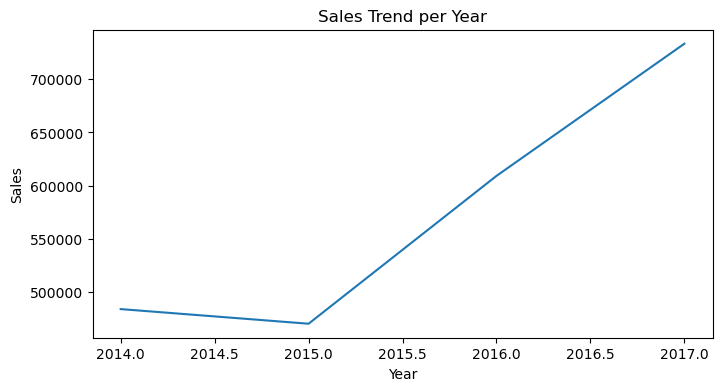

In [11]:
#Sales per year
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(data=yearly_sales, x="Year", y="Sales")
plt.title("Sales Trend per Year")
plt.show()

In [ ]:
**Insight:**
Sales show consistent growth from 2014 to 2017, indicating overall business expansion.

### 4.2 Monthly Sales Trend

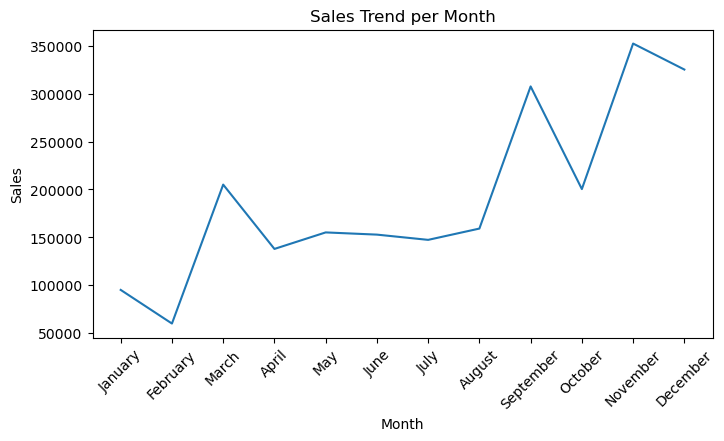

In [12]:
#Sales per month
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()
df["Month_Number"] = df["Order Date"].dt.month
df["Month"] = df["Order Date"].dt.month_name()
monthly_sales = (
    df.groupby(["Month_Number", "Month"])["Sales"]
      .sum()
      .reset_index()
      .sort_values("Month_Number")
)

plt.figure(figsize=(8,4))
sns.lineplot(data=monthly_sales, x="Month", y="Sales")
plt.title("Sales Trend per Month")
plt.xticks(rotation=45)
plt.show()

### 4.3 Monthly Sales Trend by Year

In [13]:
#Discovering seasonality
monthly_yearly = (
    df.groupby(["Year", "Month_Number", "Month"])["Sales"]
      .sum()
      .reset_index()
      .sort_values(["Year", "Month_Number"])
)

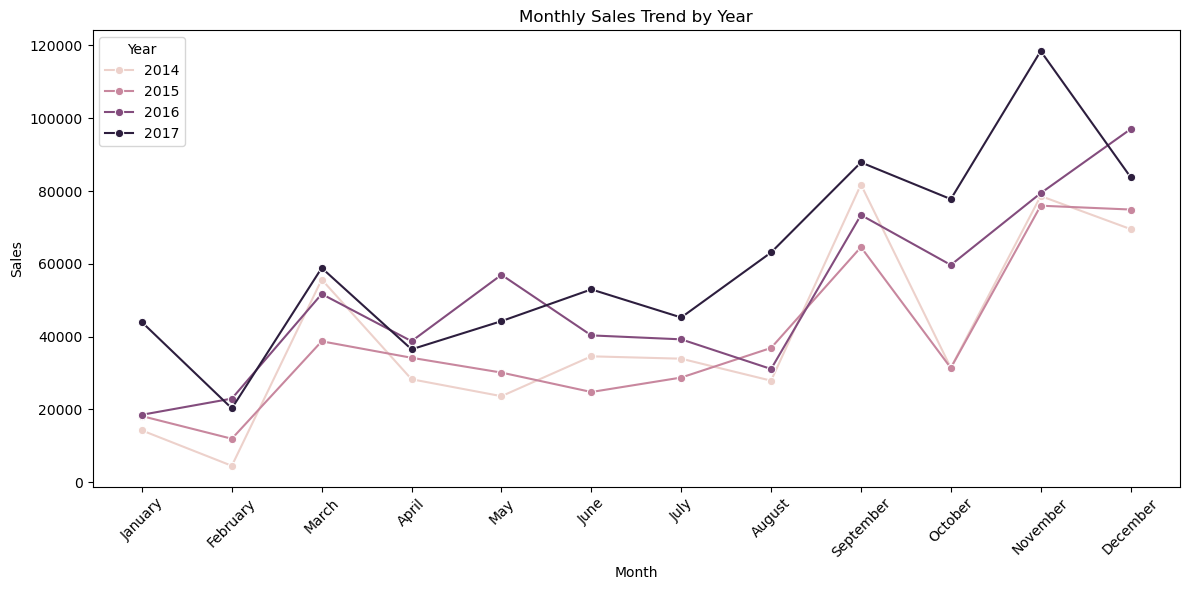

In [14]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_yearly,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend by Year")
plt.tight_layout()
plt.show()

In [ ]:
**Insight:**
Sales exhibit clear seasonality, with consistent peaks during Q4 (September–December), particularly in November. February represents the weakest month across all years. Additionally, year-over-year growth amplifies the Q4 peak, indicating both structural growth and recurring seasonal demand patterns.

### 4.4 Sales by Day of Week

In [19]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Weekday'] = df['Order Date'].dt.day_name()

df[['Order Date', 
    'Order Year', 
    'Order Month', 
    'Order Month Name', 
    'Order Weekday']].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Weekday
0,2016-11-08,2016,11,November,Tuesday
1,2016-11-08,2016,11,November,Tuesday
2,2016-06-12,2016,6,June,Sunday
3,2015-10-11,2015,10,October,Sunday
4,2015-10-11,2015,10,October,Sunday


In [22]:
sales_by_weekday = (
    df.groupby('Order Weekday')['Sales']
      .sum()
      .sort_values(ascending=False)
)

sales_by_weekday

Order Weekday
Monday       428937.8157
Friday       427692.2593
Sunday       385353.8464
Saturday     357984.6830
Thursday     321965.7785
Tuesday      287209.5022
Wednesday     88056.9752
Name: Sales, dtype: float64

In [23]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

sales_by_weekday_ordered = sales_by_weekday.reindex(weekday_order)

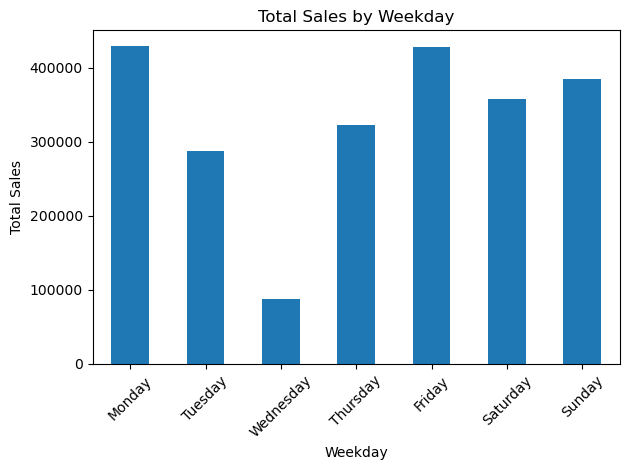

In [24]:
sales_by_weekday_ordered.plot(kind='bar')
plt.title('Total Sales by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight: Monday shows the highest total sales across the week**
    
This suggests customers concentrate purchases at the beginning of the week, possibly after weekend planning or due to business-related purchasing cycles.
Lower-performing days could represent opportunities for promotions or operational adjustments.


## 5. Geographic Performance


### 5.1 Sales by State
This section evaluates sales distribution across geographic regions to identify top-performing markets and potential expansion opportunities.

In [32]:
#Sales per state
sales_by_state = df.groupby('State').agg({'Sales':'sum'}).sort_values('Sales', ascending=False).reset_index()
print(sales_by_state.head(10)) 

          State        Sales
0    California  457687.6315
1      New York  310876.2710
2         Texas  170188.0458
3    Washington  138641.2700
4  Pennsylvania  116511.9140
5       Florida   89473.7080
6      Illinois   80166.1010
7          Ohio   78258.1360
8      Michigan   76269.6140
9      Virginia   70636.7200


C:\Users\egutierrez15\AppData\Local\Temp\ipykernel_32040\2157055438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


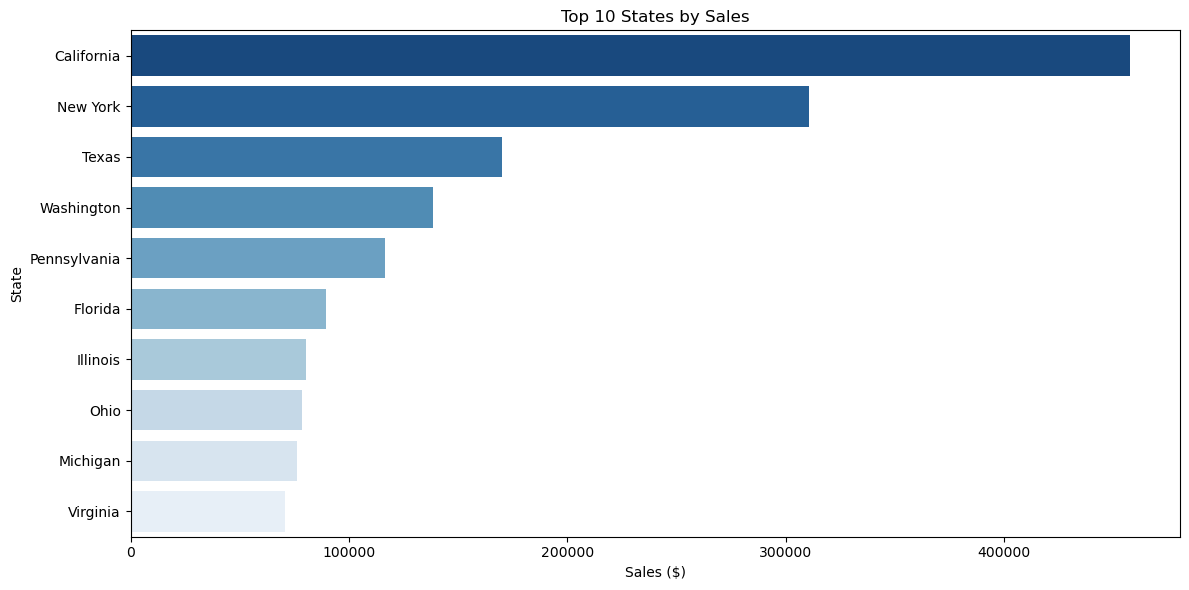

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    x='Sales', 
    y='State', 
    data=sales_by_state.head(10),  # top 10
    palette='Blues_r'
)
plt.title('Top 10 States by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [39]:
sales_by_state = (
    df.groupby("State")[["Sales", "Profit"]]
    .sum()
    .reset_index()
    .sort_values(by="Sales", ascending=False)
)

### 5.2 Sales vs Profit by State

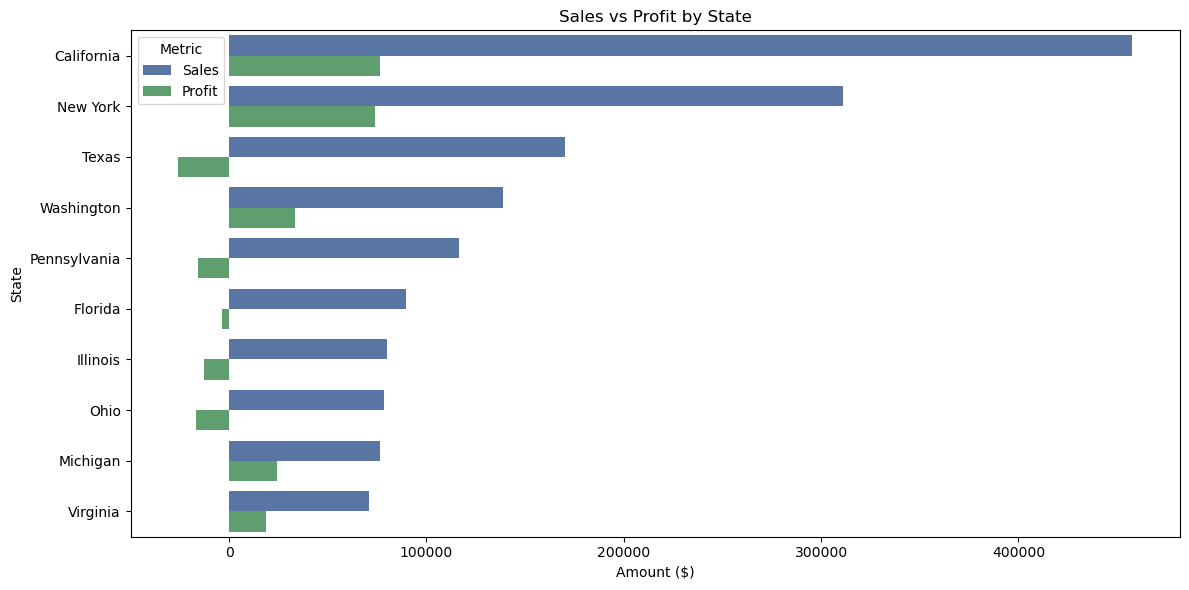

In [44]:
# Sales vs Profit by State
city_melted = sales_by_state.head(10).melt(
    id_vars='State',
    value_vars=['Sales','Profit'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Amount',
    y='State',
    hue='Metric',
    data=city_melted,
    palette=['#4c72b0', '#55a868']
)

plt.title('Sales vs Profit by State')
plt.xlabel('Amount ($)')
plt.ylabel('State')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

**Key Insight:**
High sales volume does not necessarily translate into profitability.
States such as Texas and Pennsylvania rank among the top in revenue generation, yet operate at a loss, indicating margin inefficiencies, excessive discounting, or high operational costs.

Mid-tier revenue states such as Michigan and Virginia achieve strong profitability, suggesting more efficient cost structures compared to higher-revenue but loss-generating states.

### 5.3 States with Negative Profit Margin

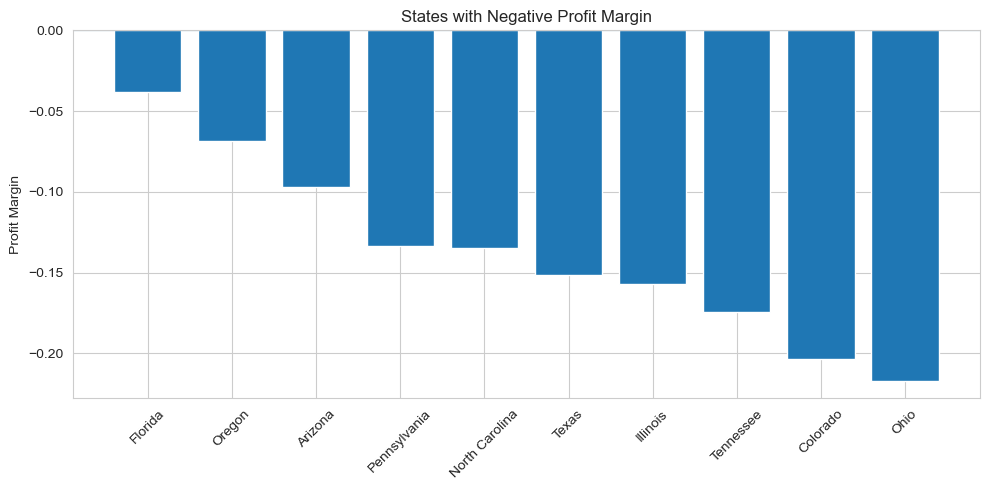

In [77]:
negative_margin = margin_sorted[margin_sorted["Profit_Margin"] < 0]

plt.figure(figsize=(10,5))
plt.bar(negative_margin["State"], negative_margin["Profit_Margin"])

plt.axhline(0)
plt.xticks(rotation=45)
plt.title("States with Negative Profit Margin")
plt.ylabel("Profit Margin")

plt.tight_layout()
plt.show()

### 5.4 Cities with Negative Profit Margin

In [79]:
worst_cities = (
    df.groupby(["State","City"])["Profit"]
      .sum()
      .reset_index()
      .sort_values(by="Profit")
      .head(5)
)

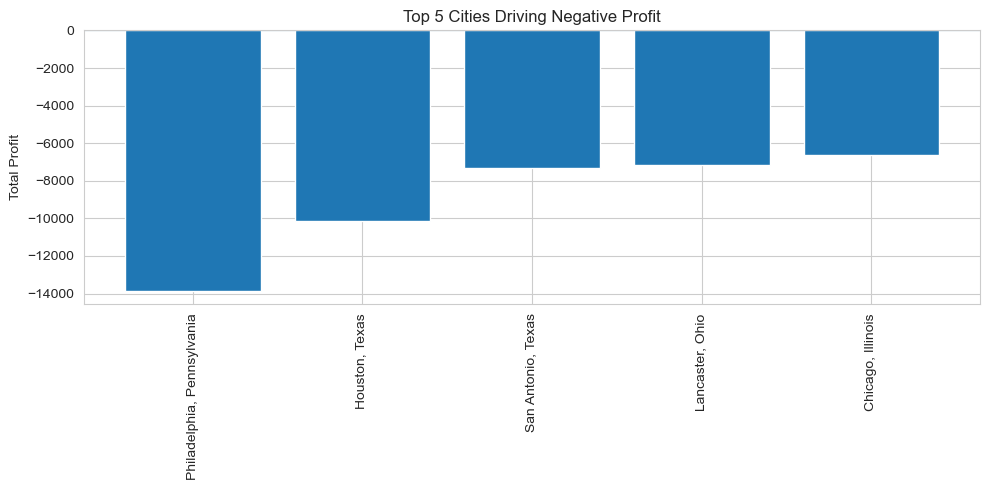

In [82]:
import matplotlib.pyplot as plt

worst_cities["Label"] = worst_cities["City"] + ", " + worst_cities["State"]

plt.figure(figsize=(10,5))
plt.bar(worst_cities["Label"], worst_cities["Profit"])
plt.axhline(0)
plt.xticks(rotation=90)
plt.title("Top 5 Cities Driving Negative Profit")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

In [46]:
#Texas cities
texas_cities = (
    df[df["State"] == "Texas"]
    .groupby("City")[["Sales","Profit"]]
    .sum()
    .sort_values("Profit")
)

texas_cities.head(10)

,Sales,Profit
City,,
Houston,64504.7604,-10153.5485
San Antonio,21843.5280,-7299.0502
Dallas,20131.9322,-2846.5257
Round Rock,4854.0528,-1183.4313
Huntsville,6710.6168,-843.4264
Waco,606.1072,-520.1034
Carrollton,2200.6460,-470.2139
Tyler,347.2060,-443.7086
Amarillo,3773.0628,-387.9683


In [48]:
#Philadelphia cities
pennsylvania_cities = (
    df[df["State"] == "Pennsylvania"]
    .groupby("City")[["Sales", "Profit"]]
    .sum()
    .reset_index()
    .sort_values("Profit")
)

pennsylvania_cities

,City,Sales,Profit
5,Philadelphia,109077.013,-13837.7674
2,Bethlehem,1689.634,-1003.0958
6,Reading,873.712,-268.7642
0,Allentown,853.252,-226.4504
4,Lancaster,1211.395,-168.8876
7,York,817.978,-102.1692
1,Altoona,20.451,-1.1835
3,Chester,1968.479,48.3578


**Key Insight:**

Profitability issues appear to be structural in certain high-revenue states. 
All analyzed cities in Texas show negative profit, while in Pennsylvania nearly all cities operate at a loss with only one exception.

This pattern suggests that profitability challenges are not limited to isolated markets but may reflect broader pricing, cost structure, or product mix inefficiencies within these states.

## 6. Product Performance

### 6.1 Sales by Category

In [26]:
#Total Sales by Category
category_summary = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
print(category_summary)

          Category        Sales       Profit
0        Furniture  741999.7953   18451.2728
1  Office Supplies  719047.0320  122490.8008
2       Technology  836154.0330  145454.9481


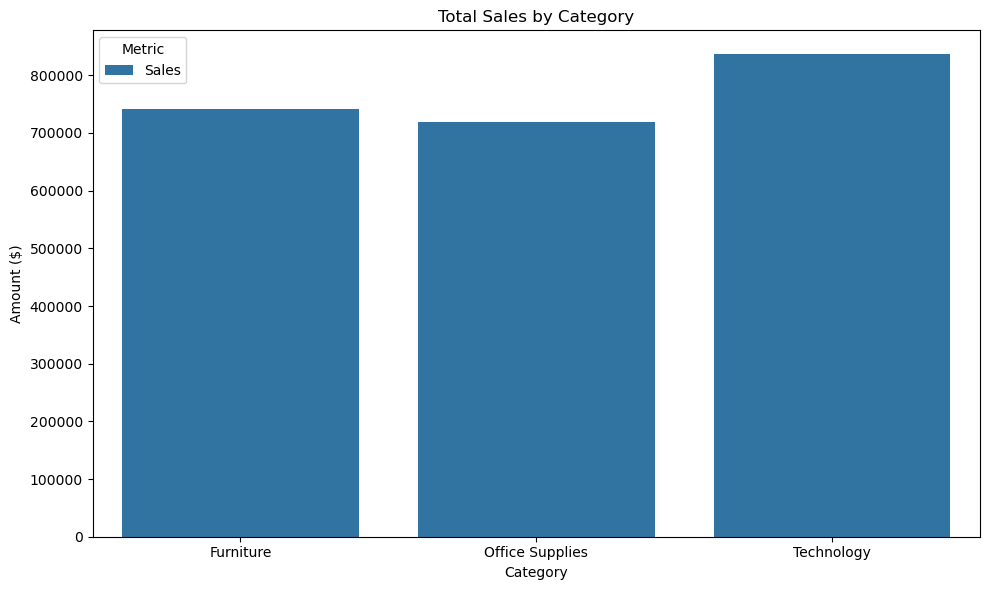

In [27]:
#Graphic sales by category
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = category_summary.melt(id_vars='Category', value_vars=['Sales'],
                                  var_name='Metric', value_name='Amount')

plt.figure(figsize=(10,6))

sns.barplot(data=df_melted, x='Category', y='Amount', hue='Metric')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
State-level losses are largely driven by major metropolitan areas. For example, Pennsylvania’s negative profitability is primarily explained by losses in Philadelphia, while Texas faces structural challenges across multiple cities including Houston and San Antonio. This suggests localized margin inefficiencies rather than uniform statewide underperformance.

### 6.2 Sales and Profit by Subcategory

In [29]:
#Total sales by subcategory
subcategory_summary = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
print(subcategory_summary)


   Sub-Category        Sales      Profit
0   Accessories  167380.3180  41936.6357
1    Appliances  107532.1610  18138.0054
2           Art   27118.7920   6527.7870
3       Binders  203412.7330  30221.7633
4     Bookcases  114879.9963  -3472.5560
5        Chairs  328449.1030  26590.1663
6       Copiers  149528.0300  55617.8249
7     Envelopes   16476.4020   6964.1767
8     Fasteners    3024.2800    949.5182
9   Furnishings   91705.1640  13059.1436
10       Labels   12486.3120   5546.2540
11     Machines  189238.6310   3384.7569
12        Paper   78479.2060  34053.5693
13       Phones  330007.0540  44515.7306
14      Storage  223843.6080  21278.8264
15     Supplies   46673.5380  -1189.0995
16       Tables  206965.5320 -17725.4811


AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_layo'

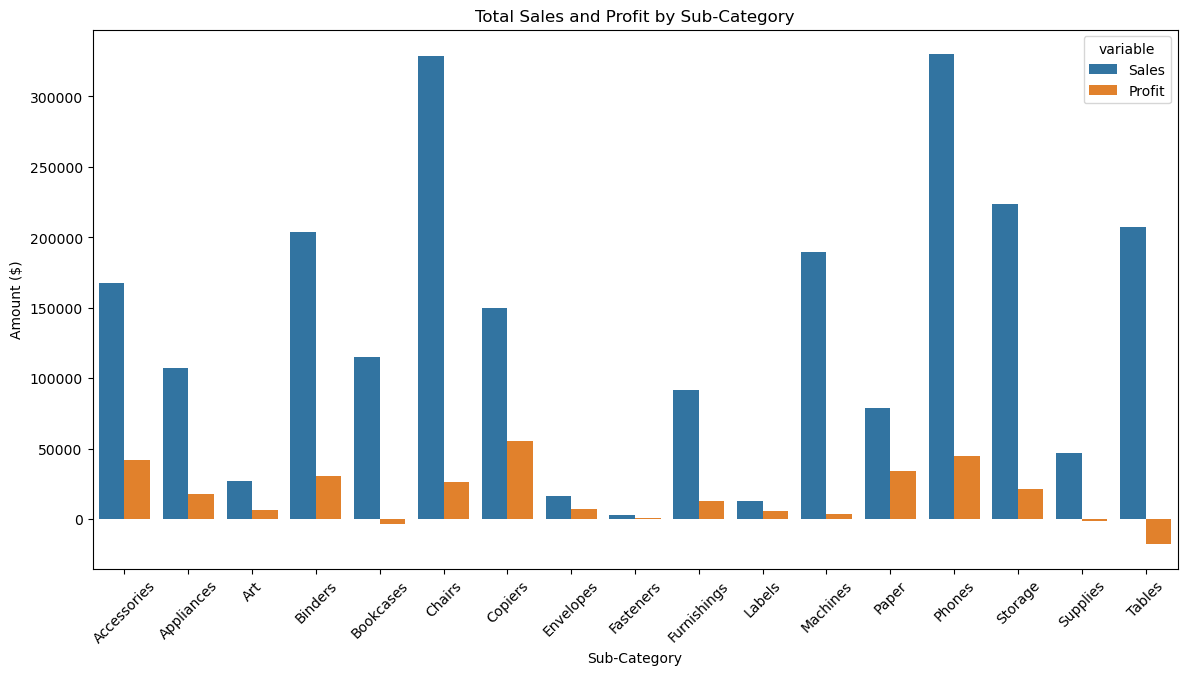

In [30]:
#graphic
plt.figure(figsize=(14,7))
sns.barplot(data=subcategory_summary.melt(id_vars='Sub-Category', value_vars=['Sales', 'Profit']),
            x='Sub-Category', y='value', hue='variable')
plt.title('Total Sales and Profit by Sub-Category')
plt.ylabel('Amount ($)')
plt.xlabel('Sub-Category')
plt.xticks(rotation=45)
plt.tight_layo


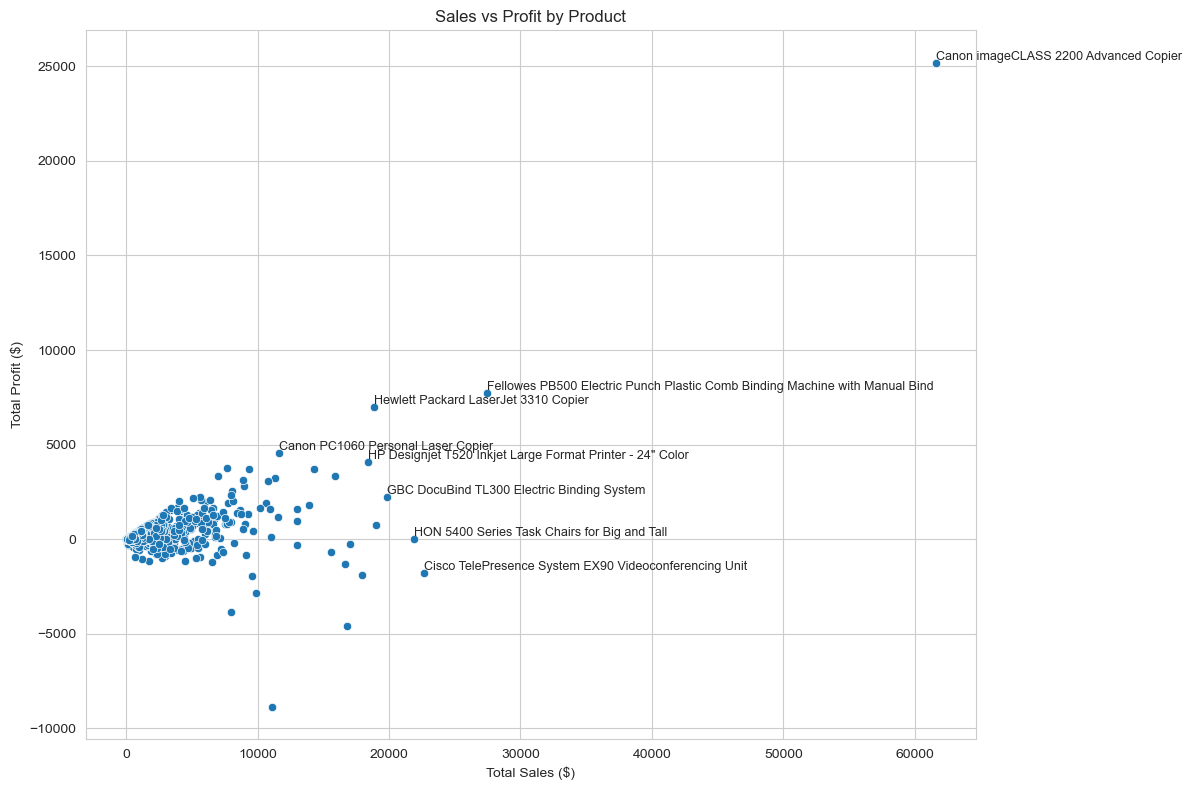

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el resumen
product_summary = df.groupby('Product Name').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()

plt.figure(figsize=(12,8))
sns.scatterplot(data=product_summary, x='Sales', y='Profit')

# Seleccionar productos top para etiquetar
top_sales = product_summary.nlargest(5, 'Sales')
top_profit = product_summary.nlargest(5, 'Profit')

# Combinar sin repetir
top_products = pd.concat([top_sales, top_profit]).drop_duplicates(subset='Product Name')

# Agregar etiquetas
for i, row in top_products.iterrows():
    plt.text(row['Sales'], row['Profit'], row['Product Name'], fontsize=9,
             horizontalalignment='left', verticalalignment='bottom')

plt.title('Sales vs Profit by Product')
plt.xlabel('Total Sales ($)')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()


### Key Insight

Most products generate relatively low sales and profit, while a small number of high-performing items drive a disproportionate share of profitability. 

However, some products with high sales volumes exhibit low or even negative profit, indicating potential pricing inefficiencies or high associated costs.


## 7. Discount Impact Analysis


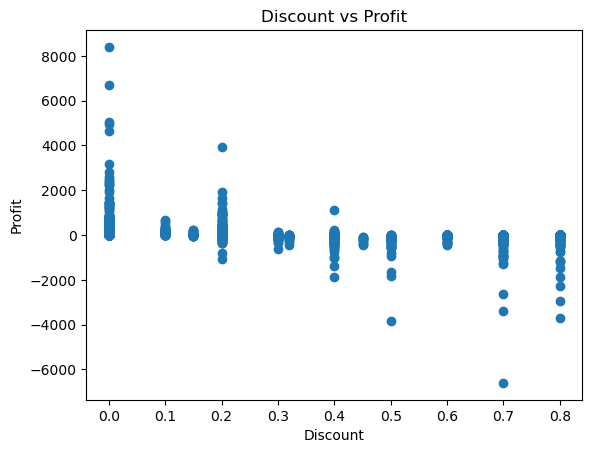

In [51]:
import matplotlib.pyplot as plt

plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()


In [53]:
#Descount level
df['Discount Level'] = pd.cut(
    df['Discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
)


In [54]:
discount_profit = (
    df.groupby('Discount Level')['Profit']
      .mean()
      .reset_index()
)

discount_profit

C:\Users\egutierrez15\AppData\Local\Temp\ipykernel_32040\3980214514.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Discount Level')['Profit']


,Discount Level,Profit
0,0-10%,96.055074
1,10-20%,24.738824
2,20-30%,-45.679636
3,30-40%,-109.219691
4,40-50%,-298.695314
5,50%+,-89.438144


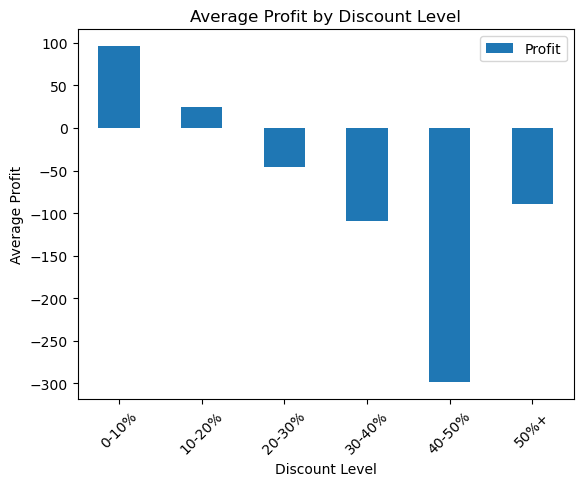

In [55]:
discount_profit.plot(x='Discount Level', y='Profit', kind='bar')
plt.title('Average Profit by Discount Level')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()


### Key Insight

Higher discount levels tend to be associated with lower profitability. 
While some discounted transactions remain profitable, larger discounts frequently correspond with negative profit outcomes.

This suggests that aggressive discount strategies may contribute to margin compression, particularly when applied to already low-margin products.


## 8. Strategic Insights & Recommendations


### Business Recommendations

- Review pricing and cost structures in loss-generating states such as Texas and Pennsylvania to identify operational inefficiencies.

- Reevaluate discount strategies, particularly for low-margin products, to prevent further margin erosion.

- Prioritize high-margin product categories such as Technology to strengthen overall profitability.

- Monitor product-level profitability to identify items that generate strong sales but contribute little or negative profit.

- Implement more targeted discount policies that balance revenue growth with sustainable profit margins.